# Feature Engineering v2

Referans: Kaya & Kalay, IEEE Access 2025

**Hedef:** Her segment (durak_i → durak_i+1) için `travel_time_min` tahmini.

**Kararlar:**
- Zaman filtresi: 06:00–24:00
- GTFS eşleşmeyenler: çıkarılır
- `congestion_ratio` yoksa: 1.0 (serbest akış) ile doldurulur
- `deviation_from_schedule` direkt feature değil — önceki segmentin lag'ı olarak kullanılır (target leakage önleme)

In [1]:
import os
import math
import sqlite3
import numpy as np
import pandas as pd
from collections import defaultdict
from datetime import datetime

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
COLLECTOR_DIR = os.path.join(PROJECT_ROOT, 'data_collector')
GTFS_DIR     = os.path.join(PROJECT_ROOT, 'data', 'bus-eshot-gtfs')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'collected_data')
OUTPUT_CSV   = os.path.join(OUTPUT_DIR, 'route_502_features_v2.csv')

DB_CANDIDATES = [
    os.path.join(OUTPUT_DIR, 'eshot_buses.db'),
    os.path.join(COLLECTOR_DIR, 'collected_data', 'eshot_buses.db'),
    os.path.join(COLLECTOR_DIR, 'collected_data', 'route_502_realtime.db'),
]
DB_PATH = next((p for p in DB_CANDIDATES if os.path.exists(p)), None)

import sys
sys.path.insert(0, COLLECTOR_DIR)
from config import STOPS_DIR0, STOPS_DIR1

if DB_PATH:
    print(f'DB: {DB_PATH}  ({os.path.getsize(DB_PATH)/1024:.1f} KB)')
else:
    raise FileNotFoundError('DB bulunamadi. collected_data/eshot_buses.db dosyasini kopyala.')

DB: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\data_collector\collected_data\route_502_realtime.db  (2060516.0 KB)


## Adım 1 — Ham Segmentleri Oluştur

**Düzeltmeler (v1 → v2):**
- `seq == prev_seq` (GPS jitter): new_trip açmak yerine o event atlanır
- `seq > prev_seq` (sefer sonu): new_trip açılır

In [2]:
def build_segments(db_path):
    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row
    rows = conn.execute("""
        SELECT otobus_id, route_id, yon, stop_id, stop_seq, stop_name, timestamp
        FROM trip_events
        WHERE event_type = 'arrival'
        ORDER BY otobus_id, yon, timestamp
    """).fetchall()
    conn.close()
    print(f'Toplam arrival eventi: {len(rows)}')

    bus_events = defaultdict(list)
    for row in rows:
        key = (row['otobus_id'], row['yon'], row['route_id'])
        bus_events[key].append({
            'ts':        datetime.strptime(row['timestamp'], '%Y-%m-%d %H:%M:%S'),
            'stop_seq':  row['stop_seq'],
            'stop_id':   row['stop_id'],
            'stop_name': row['stop_name'],
        })

    all_segments = []
    for (bus_id, yon, route_id), events in bus_events.items():
        current_trip = []
        prev_seq = None
        prev_ts  = None

        for ev in events:
            seq = ev['stop_seq']
            ts  = ev['ts']

            if prev_seq is not None:
                gap = (ts - prev_ts).total_seconds()

                if gap > 1800 or seq > prev_seq:
                    # 30 dk boşluk veya seq arttı → yeni sefer
                    all_segments.extend(_extract_segments(current_trip, bus_id, yon, route_id))
                    current_trip = []
                    prev_seq = None
                    prev_ts  = None
                elif seq == prev_seq:
                    # GPS jitter: aynı durağa tekrar gelme, event atla
                    continue
                # seq < prev_seq: normal ilerleme

            current_trip.append(ev)
            prev_seq = seq
            prev_ts  = ts

        all_segments.extend(_extract_segments(current_trip, bus_id, yon, route_id))

    return all_segments


def _extract_segments(events, bus_id, yon, route_id):
    if len(events) < 2:
        return []
    segs = []
    trip_start_ts = events[0]['ts']

    for i in range(1, len(events)):
        prev = events[i - 1]
        curr = events[i]

        if curr['stop_seq'] != prev['stop_seq'] - 1:
            continue

        travel_sec = (curr['ts'] - prev['ts']).total_seconds()
        travel_min = travel_sec / 60.0

        if not (0.33 <= travel_min <= 15):
            continue

        # Zaman filtresi: 06:00–24:00
        if curr['ts'].hour < 6:
            continue

        segs.append({
            'bus_id':            bus_id,
            'route_id':          route_id,
            'yon':               yon,
            'date':              trip_start_ts.strftime('%Y-%m-%d'),
            'trip_start_time':   trip_start_ts.strftime('%H:%M:%S'),
            'arrival_timestamp': curr['ts'].strftime('%Y-%m-%d %H:%M:%S'),
            'from_stop_seq':     prev['stop_seq'],
            'to_stop_seq':       curr['stop_seq'],
            'from_stop_name':    prev['stop_name'],
            'to_stop_name':      curr['stop_name'],
            'travel_seconds':    round(travel_sec, 1),
            'travel_time_min':   round(travel_min, 3),
        })
    return segs


raw_segments = build_segments(DB_PATH)
df = pd.DataFrame(raw_segments)
print(f'Toplam segment: {len(df)}')
if len(df) > 0:
    print(f'Tarih aralığı: {df["date"].min()} – {df["date"].max()}')
    print(f'\nHedef (travel_time_min):')
    print(df['travel_time_min'].describe().round(3))
df.head()

Toplam arrival eventi: 641814
Toplam segment: 305954
Tarih aralığı: 2026-04-02 – 2026-06-05

Hedef (travel_time_min):
count    305954.000
mean          1.172
std           1.114
min           0.433
25%           0.533
50%           1.050
75%           1.583
max          15.000
Name: travel_time_min, dtype: float64


,bus_id,route_id,yon,date,trip_start_time,arrival_timestamp,from_stop_seq,to_stop_seq,from_stop_name,to_stop_name,travel_seconds,travel_time_min
0,1603,268,0,2026-04-17,06:31:50,2026-04-17 06:35:01,19,18,Yeşil Köşk,Öğrenci Köyü,191.0,3.183
1,1603,268,0,2026-04-17,06:31:50,2026-04-17 06:36:05,18,17,Öğrenci Köyü,Okullar,64.0,1.067
2,1603,268,0,2026-04-17,06:31:50,2026-04-17 06:37:40,15,14,Hasan Tahsin Özel Eğitim Okulu,Okul,63.0,1.050
3,1603,268,0,2026-04-17,06:31:50,2026-04-17 06:38:12,14,13,Okul,Adliye Lojmanları,32.0,0.533
4,1603,268,0,2026-04-17,06:31:50,2026-04-17 06:38:44,13,12,Adliye Lojmanları,Çağla,32.0,0.533


## Adım 2 — Zamansal Featurelar

| Feature | Açıklama |
|---------|----------|
| `hour`, `day_of_week` | Ham sayılar (referans için) |
| `day_type` | 0=hafta içi, 1=hafta sonu |
| `time_block` | 0=sabah pik, 1=gündüz, 2=akşam pik, 3=gece |
| `hour_sin/cos` | Çembersel encoding — 23 ile 0 arası fark 1 saat |
| `dow_sin/cos` | Çembersel encoding — Pazar ile Pazartesi komşu |

In [3]:
df['arrival_timestamp'] = pd.to_datetime(df['arrival_timestamp'])
df['hour']        = df['arrival_timestamp'].dt.hour
df['day_of_week'] = df['arrival_timestamp'].dt.dayofweek  # 0=Pazartesi
df['day_type']    = (df['day_of_week'] >= 5).astype(int)

def get_time_block(hour):
    if 6  <= hour < 10: return 0  # sabah pik
    if 10 <= hour < 17: return 1  # gündüz
    if 17 <= hour < 20: return 2  # akşam pik
    return 3                      # gece

df['time_block'] = df['hour'].apply(get_time_block)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)

block_labels = {0: 'sabah_pik', 1: 'gündüz', 2: 'akşam_pik', 3: 'gece'}
print('Zaman bloğu:', df['time_block'].map(block_labels).value_counts().to_dict())
print('Hafta içi/sonu:', df['day_type'].value_counts().to_dict())

Zaman bloğu: {'gündüz': 151545, 'sabah_pik': 79185, 'akşam_pik': 50141, 'gece': 25083}
Hafta içi/sonu: {0: 226910, 1: 79044}


## Adım 3 — GTFS Planlanmış Süre

**Eşleştirme notu:** Segmentlerde seq azalır (from=N, to=N-1), GTFS'te artar.  
`segment.to_seq` ↔ `gtfs.from_seq`, `segment.from_seq` ↔ `gtfs.to_seq`

GTFS eşleşmesi bulunamayan satırlar çıkarılır (`inner join`).

In [4]:
trips_gtfs = pd.read_csv(os.path.join(GTFS_DIR, 'trips.txt'))
stop_times = pd.read_csv(os.path.join(GTFS_DIR, 'stop_times.txt'))

route502_ids = set(trips_gtfs[trips_gtfs['route_id'] == 502]['trip_id'])
st502 = stop_times[stop_times['trip_id'].isin(route502_ids)].copy()
print(f'Route 502 GTFS kayıt: {len(st502)}')

def time_to_sec(t):
    h, m, s = t.strip().split(':')
    return int(h)*3600 + int(m)*60 + int(s)

st502['arr_sec'] = st502['arrival_time'].apply(time_to_sec)
st502['dep_sec'] = st502['departure_time'].apply(time_to_sec)
st502 = st502.sort_values(['trip_id', 'stop_sequence'])

sched_records = []
for _, grp in st502.groupby('trip_id'):
    grp = grp.sort_values('stop_sequence')
    seqs = grp['stop_sequence'].values
    deps = grp['dep_sec'].values
    arrs = grp['arr_sec'].values
    for i in range(1, len(seqs)):
        secs = arrs[i] - deps[i-1]
        if secs > 0:
            sched_records.append({'gtfs_from': int(seqs[i-1]), 'gtfs_to': int(seqs[i]), 'sched_sec': secs})

sched_avg = (
    pd.DataFrame(sched_records)
    .groupby(['gtfs_from', 'gtfs_to'])['sched_sec'].mean()
    .reset_index()
)
sched_avg['scheduled_travel_min'] = (sched_avg['sched_sec'] / 60).round(3)

before = len(df)
df = df.merge(
    sched_avg[['gtfs_from', 'gtfs_to', 'scheduled_travel_min']],
    left_on=['to_stop_seq', 'from_stop_seq'],
    right_on=['gtfs_from', 'gtfs_to'],
    how='inner'
).drop(columns=['gtfs_from', 'gtfs_to'])

print(f'GTFS eşleşmesi: {len(df)}/{before} ({len(df)/before*100:.1f}% kaldı)')
print(f'Planlanmış süre (dk): ort={df["scheduled_travel_min"].mean():.2f}, std={df["scheduled_travel_min"].std():.2f}')

Route 502 GTFS kayıt: 18244
GTFS eşleşmesi: 305954/305954 (100.0% kaldı)
Planlanmış süre (dk): ort=1.13, std=0.40


## Adım 4 — Lag Featurelar (Önceki Segment Bilgisi)

**Target leakage düzeltmesi:**  
`deviation = travel_time_min - scheduled_travel_min` hedeften türetildiği için direkt feature olamaz.  
Bunun yerine **önceki segmentin** değerleri lag feature olarak kullanılır — bu bilgi tahmin anında mevcuttur.

| Feature | Açıklama |
|---------|----------|
| `prev_travel_time_min` | Önceki durağa geçen gerçek süre — makalenin `elapsed_time` feature'ı |
| `prev_deviation` | Önceki segmentte plandan sapma (gecikmeler birikir) |

İlk segment (trip başı): önceki bilgi yok → 0.0 ile doldurulur (nötr varsayım).

In [5]:
# Her trip içinde segmentleri from_stop_seq'e göre sırala (azalan = ilerleme yönü)
df = df.sort_values(
    ['bus_id', 'yon', 'date', 'trip_start_time', 'from_stop_seq'],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

trip_group = ['bus_id', 'yon', 'date', 'trip_start_time']

# Önceki segmentin gerçek süresi
df['prev_travel_time_min'] = (
    df.groupby(trip_group)['travel_time_min']
    .shift(1)
    .fillna(0.0)
)

# Önceki segmentin sapması (trip içinde hesaplanır, leakage yok)
df['_deviation'] = df['travel_time_min'] - df['scheduled_travel_min']
df['prev_deviation'] = (
    df.groupby(trip_group)['_deviation']
    .shift(1)
    .fillna(0.0)
)
df = df.drop(columns=['_deviation'])

first_seg = (df['prev_travel_time_min'] == 0).sum()
print(f'Toplam segment     : {len(df)}')
print(f'İlk segment (0.0)  : {first_seg} ({first_seg/len(df)*100:.1f}%)')
print(f'\nprev_travel_time_min: ort={df["prev_travel_time_min"].mean():.2f} dk')
print(f'prev_deviation      : ort={df["prev_deviation"].mean():.2f} dk')

Toplam segment     : 305954
İlk segment (0.0)  : 38776 (12.7%)

prev_travel_time_min: ort=1.03 dk
prev_deviation      : ort=0.05 dk


## Adım 4b — Trip Pozisyon & Kümülatif Gecikme Featureları

| Feature | Açıklama |
|---------|----------|
| `segments_into_trip` | Trip içinde kaçıncı segment (0=ilk). Cold-start tespiti için temel. |
| `is_trip_start` | İlk 2 segment → 1, diğerleri → 0 (cold-start bayrağı). |
| `trip_elapsed_min` | Trip başından bu segmentin başına kadar geçen gerçek toplam süre (dk). |
| `cumulative_deviation` | Trip boyunca birikmiş toplam plandan sapma (dk). Gecikmeler birikimli — lag 1 adımda kaybolur. |
| `rolling_travel_avg3` | Önceki 3 segmentin kayan ortalaması. Kısa vadeli hız trendini yakalar. |

**Motivasyon:** Ablasyon sonucu — trip başlangıcında (stop_progress 0–33%) MAE=0.83, orta/sonda MAE=0.41.  
`prev_travel_time_min` ve `prev_deviation` trip başında 0 ile doluyor; model bağlamsız kalıyor.  
Bu yeni featurelar cold-start problemine doğrudan yanıt verir.

In [6]:

# --- Trip Pozisyon Featureları ---
# segments_into_trip: trip içinde kaçıncı segment (0=ilk)
df['segments_into_trip'] = df.groupby(trip_group).cumcount()

# is_trip_start: ilk 2 segment → 1 (cold-start bayrağı)
df['is_trip_start'] = (df['segments_into_trip'] <= 1).astype(int)

# trip_elapsed_min: trip başından bu segmentin BAŞINA kadar geçen gerçek toplam süre
df['_cumsum_tt'] = df.groupby(trip_group)['travel_time_min'].cumsum()
df['trip_elapsed_min'] = (
    df.groupby(trip_group)['_cumsum_tt']
    .shift(1)
    .fillna(0.0)
    .round(3)
)
df = df.drop(columns=['_cumsum_tt'])

# --- Kümülatif Gecikme Featureları ---
# cumulative_deviation: trip boyunca birikmiş toplam plandan sapma (dk)
# — trip başından bu segmentin BAŞINA kadar; leakage yok
df['_dev_curr'] = df['travel_time_min'] - df['scheduled_travel_min']
df['_cumdev']   = df.groupby(trip_group)['_dev_curr'].cumsum()
df['cumulative_deviation'] = (
    df.groupby(trip_group)['_cumdev']
    .shift(1)
    .fillna(0.0)
    .round(3)
)
df = df.drop(columns=['_dev_curr', '_cumdev'])

# rolling_travel_avg3: önceki 3 segmentin kayan ortalama gerçek süresi (hız trendi)
df['rolling_travel_avg3'] = (
    df.groupby(trip_group)['travel_time_min']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    .fillna(0.0)
    .round(3)
)

cold_n = df['is_trip_start'].sum()
print(f'Toplam segment         : {len(df)}')
print(f'Cold-start (is_trip_start=1): {cold_n} ({cold_n/len(df)*100:.1f}%)')
print(f'segments_into_trip     : ort={df["segments_into_trip"].mean():.1f}, max={df["segments_into_trip"].max()}')
print(f'trip_elapsed_min       : ort={df["trip_elapsed_min"].mean():.2f} dk')
print(f'cumulative_deviation   : ort={df["cumulative_deviation"].mean():.3f} dk')
print(f'rolling_travel_avg3    : ort={df["rolling_travel_avg3"].mean():.2f} dk')


Toplam segment         : 305954
Cold-start (is_trip_start=1): 62927 (20.6%)
segments_into_trip     : ort=5.8, max=22
trip_elapsed_min       : ort=7.74 dk
cumulative_deviation   : ort=0.945 dk
rolling_travel_avg3    : ort=1.12 dk


## Adım 5 — Hava Durumu Featureları

Arrival timestamp'e en yakın hava kaydıyla eşleştirilir (`merge_asof`, 2 saat tolerans).

In [7]:
conn = sqlite3.connect(DB_PATH)
weather_df = pd.read_sql_query('SELECT * FROM weather_readings ORDER BY timestamp', conn)
conn.close()
print(f'Hava kayıt sayısı: {len(weather_df)}')

WEATHER_CAT_MAP = {'clear': 0, 'cloudy': 1, 'rainy': 2, 'snowy': 3}

if len(weather_df) > 0:
    weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])
    weather_df['weather_cat_enc'] = weather_df['weather_category'].map(WEATHER_CAT_MAP).fillna(1)

    df = pd.merge_asof(
        df.sort_values('arrival_timestamp'),
        weather_df[['timestamp', 'temperature', 'humidity', 'precipitation',
                     'wind_speed', 'visibility', 'weather_category', 'weather_cat_enc']]
              .sort_values('timestamp'),
        left_on='arrival_timestamp',
        right_on='timestamp',
        direction='nearest',
        tolerance=pd.Timedelta('2h')
    ).drop(columns=['timestamp'], errors='ignore')

    matched = df['temperature'].notna().sum()
    print(f'Eşleşme: {matched}/{len(df)} ({matched/len(df)*100:.1f}%)')
    print(f'Kaynak: {weather_df["source"].value_counts().to_dict()}')
else:
    print('Hava verisi henüz yok — NaN olarak eklendi')
    for col in ['temperature', 'humidity', 'precipitation', 'wind_speed',
                'visibility', 'weather_category', 'weather_cat_enc']:
        df[col] = np.nan

# is_rainy: yağışlı/karlı durumlar için binary flag
# — 27 günlük veride sadece clear/cloudy gözlendi; bu flag düşük varyanslı featureları özetler
df['is_rainy'] = (df['weather_cat_enc'].fillna(0) >= 2).astype(int)
rainy_n = df['is_rainy'].sum()
print(f'is_rainy: {rainy_n} yağışlı segment ({rainy_n/len(df)*100:.1f}%)')
print(f'Hava kategorileri: {df["weather_category"].value_counts().to_dict() if "weather_category" in df.columns else "N/A"}')


Hava kayıt sayısı: 1529
Eşleşme: 305954/305954 (100.0%)
Kaynak: {'openweathermap': 1529}
is_rainy: 8167 yağışlı segment (2.7%)
Hava kategorileri: {'partly_cloudy': 194217, 'clear': 99657, 'rainy': 8167, 'overcast': 3913}


## Adım 6 — Trafik Featureları (TomTom)

**Düzeltme:** O(n²) nested loop yerine `merge_asof` + `by` parametresiyle O(n log n) merge.

Eşleşme bulunamazsa `congestion_ratio = 1.0` (serbest akış).

In [8]:
conn = sqlite3.connect(DB_PATH)
traffic_df = pd.read_sql_query("""
    SELECT timestamp, from_stop_seq, to_stop_seq, direction, congestion_ratio
    FROM traffic_readings ORDER BY timestamp
""", conn)
conn.close()
print(f'Trafik kayıt sayısı: {len(traffic_df)}')

if len(traffic_df) > 0:
    traffic_df['timestamp'] = pd.to_datetime(traffic_df['timestamp'])

    # merge_asof: from/to/direction'da exact match, timestamp'te nearest
    # 'yon' → 'direction' eşleştirmesi için geçici kolon
    df['direction'] = df['yon']

    df = pd.merge_asof(
        df.sort_values('arrival_timestamp'),
        traffic_df[['from_stop_seq', 'to_stop_seq', 'direction', 'timestamp', 'congestion_ratio']]
                  .sort_values('timestamp'),
        left_on='arrival_timestamp',
        right_on='timestamp',
        by=['from_stop_seq', 'to_stop_seq', 'direction'],
        direction='nearest',
        tolerance=pd.Timedelta('30min')
    ).drop(columns=['timestamp', 'direction'], errors='ignore')

    filled = df['congestion_ratio'].isna().sum()
    df['congestion_ratio'] = df['congestion_ratio'].fillna(1.0)
    print(f'Eşleşen: {len(df)-filled}/{len(df)}, {filled} satır 1.0 ile dolduruldu')
else:
    print('Trafik verisi henüz yok — congestion_ratio=1.0 atandı')
    df['congestion_ratio'] = 1.0

# congestion_x_scheduled: tıkanıklığın planlanmış süreyle interaksiyonu
# — tıkanıklık etkisi uzun segmentlerde daha büyük; bu interaksiyon bunu yakalar
df['congestion_x_scheduled'] = (df['congestion_ratio'] * df['scheduled_travel_min']).round(3)
print(f'congestion_ratio      : ort={df["congestion_ratio"].mean():.3f}')
print(f'congestion_x_scheduled: ort={df["congestion_x_scheduled"].mean():.3f}')


Trafik kayıt sayısı: 140670
Eşleşen: 0/305954, 305954 satır 1.0 ile dolduruldu
congestion_ratio      : ort=1.000
congestion_x_scheduled: ort=1.132


## Adım 7 — Mekansal Featurelar

**Düzeltmeler:**
- `iterrows()` → vektörize Haversine
- `stop_progress` formülü: `(max_seq - to_seq) / (max_seq - 1)` → son durağa varışta 1.0

In [9]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return (R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))).round(1)


# Durak koordinatlarını DataFrame'e çevir, merge ile ekle (join = vektörize)
coord_rows = (
    [{'yon': 0, 'seq': s['seq'], 'lat': s['lat'], 'lon': s['lon']} for s in STOPS_DIR0] +
    [{'yon': 1, 'seq': s['seq'], 'lat': s['lat'], 'lon': s['lon']} for s in STOPS_DIR1]
)
coord_df = pd.DataFrame(coord_rows)

df = df.merge(
    coord_df.rename(columns={'seq': 'from_stop_seq', 'lat': 'from_lat', 'lon': 'from_lon'}),
    on=['yon', 'from_stop_seq'], how='left'
).merge(
    coord_df.rename(columns={'seq': 'to_stop_seq', 'lat': 'to_lat', 'lon': 'to_lon'}),
    on=['yon', 'to_stop_seq'], how='left'
)

df['distance_m'] = haversine_vectorized(
    df['from_lat'], df['from_lon'], df['to_lat'], df['to_lon']
)

# stop_progress: to_seq=1 (son durak) → 1.0, to_seq=max_seq-1 (ilk segment) → küçük değer
max_seq = {0: max(s['seq'] for s in STOPS_DIR0),
           1: max(s['seq'] for s in STOPS_DIR1)}

df['stop_progress'] = df.apply(
    lambda r: round((max_seq[int(r['yon'])] - int(r['to_stop_seq'])) / (max_seq[int(r['yon'])] - 1), 3),
    axis=1
)

df = df.drop(columns=['from_lat', 'from_lon', 'to_lat', 'to_lon'])

print(f'distance_m: ort={df["distance_m"].mean():.0f}m, std={df["distance_m"].std():.0f}m, NaN={df["distance_m"].isna().sum()}')
print(f'stop_progress: min={df["stop_progress"].min()}, max={df["stop_progress"].max()}')

distance_m: ort=260m, std=126m, NaN=0
stop_progress: min=0.032, max=1.0


## Adım 8 — Final Dataset

**Feature özeti (27 feature — v2.1):**

| Grup | Featurelar |
|------|-----------|
| Zamansal | `hour`, `day_of_week`, `day_type`, `time_block`, `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos` |
| Mekansal | `stop_progress`, `distance_m` |
| Sequential (lag) | `prev_travel_time_min`, `prev_deviation` |
| **Trip Pozisyon** | `segments_into_trip`, `is_trip_start`, `trip_elapsed_min` |
| **Kümülatif Gecikme** | `cumulative_deviation`, `rolling_travel_avg3` |
| GTFS | `scheduled_travel_min` |
| Hava | `temperature`, `humidity`, `precipitation`, `wind_speed`, `visibility`, `weather_cat_enc`, `is_rainy` |
| Trafik | `congestion_ratio`, `congestion_x_scheduled` |

**v2 → v2.1 değişiklikleri:**
- `segments_into_trip`, `is_trip_start`, `trip_elapsed_min` eklendi — cold-start problemi (MAE 0.83 → hedef ~0.60)
- `cumulative_deviation`, `rolling_travel_avg3` eklendi — birikimli gecikme ve hız trendi
- `is_rainy` eklendi — ablasyon sonucu hava categorileri gürültülü; binary flag özet sağlar
- `congestion_x_scheduled` eklendi — tıkanıklık×tarifye interaksiyonu

In [10]:
ID_COLS = [
    'date', 'bus_id', 'route_id', 'yon', 'trip_start_time',
    'from_stop_seq', 'to_stop_seq', 'from_stop_name', 'to_stop_name',
    'arrival_timestamp', 'travel_seconds',
]

FEATURE_COLS = [
    # Zamansal
    'hour', 'day_of_week', 'day_type', 'time_block',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    # Mekansal
    'stop_progress', 'distance_m',
    # Sequential lag
    'prev_travel_time_min', 'prev_deviation',
    # Trip pozisyon (cold-start)
    'segments_into_trip', 'is_trip_start', 'trip_elapsed_min',
    # Kümülatif gecikme
    'cumulative_deviation', 'rolling_travel_avg3',
    # GTFS
    'scheduled_travel_min',
    # Hava
    'temperature', 'humidity', 'precipitation', 'wind_speed', 'visibility',
    'weather_cat_enc', 'is_rainy',
    # Trafik
    'congestion_ratio', 'congestion_x_scheduled',
]

TARGET_COL = 'travel_time_min'

avail_id   = [c for c in ID_COLS      if c in df.columns]
avail_feat = [c for c in FEATURE_COLS if c in df.columns]
df_final   = df[avail_id + avail_feat + [TARGET_COL]].copy()

print(f'Final dataset: {df_final.shape[0]} satır, {len(avail_feat)} feature')
print(f'Eksik feature: {[c for c in FEATURE_COLS if c not in df.columns]}')
print(f'\nNaN özeti:')
nan_s = df_final[avail_feat].isna().sum()
print(nan_s[nan_s > 0].to_string() if nan_s.sum() > 0 else 'Yok')
print(f'\nHedef (travel_time_min):')
print(df_final[TARGET_COL].describe().round(3))
print(f'\nYeni featurelar özeti:')
new_feats = ['segments_into_trip', 'is_trip_start', 'trip_elapsed_min',
             'cumulative_deviation', 'rolling_travel_avg3', 'is_rainy', 'congestion_x_scheduled']
print(df_final[[f for f in new_feats if f in df_final.columns]].describe().round(3))


Final dataset: 305954 satır, 27 feature
Eksik feature: []

NaN özeti:
Yok

Hedef (travel_time_min):
count    305954.000
mean          1.172
std           1.114
min           0.433
25%           0.533
50%           1.050
75%           1.583
max          15.000
Name: travel_time_min, dtype: float64

Yeni featurelar özeti:
       segments_into_trip  is_trip_start  trip_elapsed_min  \
count          305954.000     305954.000        305954.000   
mean                5.821          0.206             7.743   
std                 4.371          0.404             6.564   
min                 0.000          0.000             0.000   
25%                 2.000          0.000             2.666   
50%                 5.000          0.000             6.500   
75%                 9.000          0.000            11.201   
max                22.000          1.000            55.367   

       cumulative_deviation  rolling_travel_avg3    is_rainy  \
count            305954.000           305954.000  30595

In [11]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_final.to_csv(OUTPUT_CSV, index=False)
print(f'Kaydedildi: {OUTPUT_CSV}')
print(f'Boyut: {os.path.getsize(OUTPUT_CSV)/1024:.1f} KB — {len(df_final)} satır, {len(df_final.columns)} kolon')

Kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\collected_data\route_502_features_v2.csv
Boyut: 85236.7 KB — 305954 satır, 39 kolon


## Ek — Görselleştirme

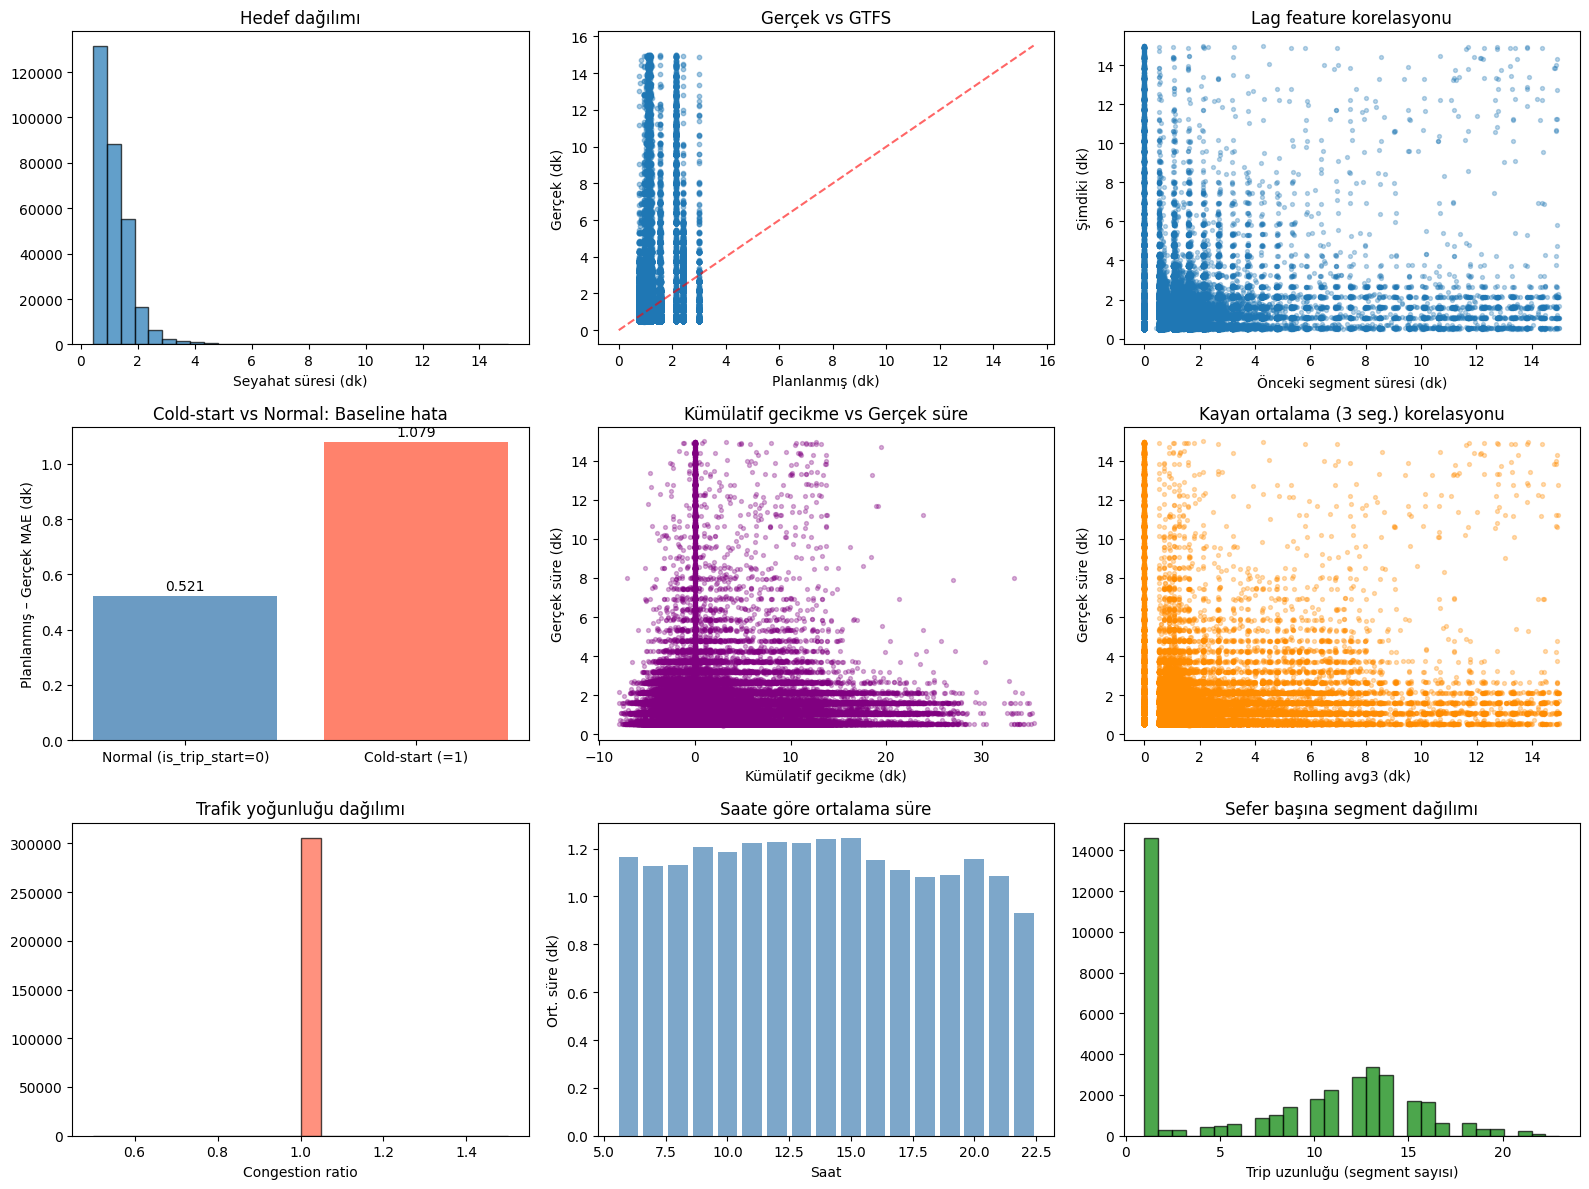

Kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\figures\feature_engineering_v2_eda.png


In [12]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('matplotlib kurulu değil'); raise SystemExit

if len(df_final) < 10:
    print('Görselleştirme için yetersiz veri.')
else:
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))

    # --- Satır 1: Mevcut featurelar ---
    axes[0,0].hist(df_final[TARGET_COL], bins=30, edgecolor='black', alpha=0.7)
    axes[0,0].set_xlabel('Seyahat süresi (dk)')
    axes[0,0].set_title('Hedef dağılımı')

    axes[0,1].scatter(df_final['scheduled_travel_min'], df_final[TARGET_COL], alpha=0.4, s=10)
    lim = max(df_final['scheduled_travel_min'].max(), df_final[TARGET_COL].max()) + 0.5
    axes[0,1].plot([0, lim], [0, lim], 'r--', alpha=0.6)
    axes[0,1].set_xlabel('Planlanmış (dk)'); axes[0,1].set_ylabel('Gerçek (dk)')
    axes[0,1].set_title('Gerçek vs GTFS')

    axes[0,2].scatter(df_final['prev_travel_time_min'], df_final[TARGET_COL], alpha=0.3, s=8)
    axes[0,2].set_xlabel('Önceki segment süresi (dk)'); axes[0,2].set_ylabel('Şimdiki (dk)')
    axes[0,2].set_title('Lag feature korelasyonu')

    # --- Satır 2: Yeni trip pozisyon featureları ---
    if 'is_trip_start' in df_final.columns:
        cold_mae = df_final.groupby('is_trip_start').apply(
            lambda g: abs(g[TARGET_COL] - g['scheduled_travel_min']).mean()
        )
        bars = axes[1,0].bar(['Normal (is_trip_start=0)', 'Cold-start (=1)'],
                              cold_mae.values, color=['steelblue', 'tomato'], alpha=0.8)
        axes[1,0].set_ylabel('Planlanmış – Gerçek MAE (dk)')
        axes[1,0].set_title('Cold-start vs Normal: Baseline hata')
        for bar, val in zip(bars, cold_mae.values):
            axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    if 'cumulative_deviation' in df_final.columns:
        axes[1,1].scatter(df_final['cumulative_deviation'], df_final[TARGET_COL],
                          alpha=0.3, s=8, color='purple')
        axes[1,1].set_xlabel('Kümülatif gecikme (dk)'); axes[1,1].set_ylabel('Gerçek süre (dk)')
        axes[1,1].set_title('Kümülatif gecikme vs Gerçek süre')

    if 'rolling_travel_avg3' in df_final.columns:
        axes[1,2].scatter(df_final['rolling_travel_avg3'], df_final[TARGET_COL],
                          alpha=0.3, s=8, color='darkorange')
        axes[1,2].set_xlabel('Rolling avg3 (dk)'); axes[1,2].set_ylabel('Gerçek süre (dk)')
        axes[1,2].set_title('Kayan ortalama (3 seg.) korelasyonu')

    # --- Satır 3: Trafik & zaman ---
    axes[2,0].hist(df_final['congestion_ratio'], bins=20, edgecolor='black', alpha=0.7, color='tomato')
    axes[2,0].set_xlabel('Congestion ratio')
    axes[2,0].set_title('Trafik yoğunluğu dağılımı')

    by_hour = df_final.groupby('hour')[TARGET_COL].mean()
    axes[2,1].bar(by_hour.index, by_hour.values, alpha=0.7, color='steelblue')
    axes[2,1].set_xlabel('Saat'); axes[2,1].set_ylabel('Ort. süre (dk)')
    axes[2,1].set_title('Saate göre ortalama süre')

    if 'segments_into_trip' in df_final.columns:
        trip_len = df_final.groupby(['bus_id', 'yon', 'date', 'trip_start_time'])['segments_into_trip'].max() + 1
        axes[2,2].hist(trip_len, bins=30, edgecolor='black', alpha=0.7, color='green')
        axes[2,2].set_xlabel('Trip uzunluğu (segment sayısı)')
        axes[2,2].set_title('Sefer başına segment dağılımı')

    plt.tight_layout()
    fig_path = os.path.join(PROJECT_ROOT, 'results', 'figures', 'feature_engineering_v2_eda.png')
    os.makedirs(os.path.dirname(fig_path), exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Kaydedildi: {fig_path}')


## Adım 9 — Dwell Time Feature (v4)

**Kaynak:** `scripts/add_dwell_features.py`  
**Girdi:** `route_502_features_v3.csv` → **Çıktı:** `route_502_features_v4.csv`

Dwell time, otobüsün bir durağa varışı ile ayrılışı arasında geçen süredir.  
`trip_events` tablosunda yalnızca `arrival` olayı kayıtlı olduğundan dwell time  
`bus_positions` tablosundaki ham GPS kayıtlarından türetilmiştir:

> Otobüsün durağa **≤ 50 m** mesafede kaldığı ardışık GPS kayıtlarının toplam süresi = dwell_time_sec

| Feature | Açıklama | Aralık |
|---------|----------|--------|
| `dwell_time_sec` | Bu durağa varıştan ayrılışa kadar geçen süre (sn) | 10–600 sn |
| `prev_dwell_time_sec` | Trip içinde bir önceki durağın dwell süresi | 10–600 sn |

**Ablasyon sonucu (RF, 200 ağaç, max_depth=12, n=138.282):**

| Model | MAE (dk) | RMSE | R² | MAPE |
|-------|--------:|-----:|---:|-----:|
| RF baseline (v3, deviation_minutes çıkarıldı) | 0.4324 | 0.7744 | 0.4748 | 46.0% |
| RF + dwell_time_sec + prev_dwell_time_sec | **0.4166** | **0.7338** | **0.5286** | **44.7%** |

- MAE **%3.7 iyileşti** (0.4324 → 0.4166 dk)  
- R² **5.4 puan arttı** (0.4748 → 0.5286)  
- `dwell_time_sec` feature önem sıralamasında **3. sıraya** çıktı (%11.6),  
  yalnızca `stop_hist_median` (%30.7) ve `stop_hist_ratio` (%17.7) önünde.

**Motivasyon (PDF referansı):** *Bus Arrival Time Forecasting* notundaki  
iki aşamalı mimari önerisinden esinlenilmiştir — Stage 1: Dwell predictor,  
Stage 2: Travel predictor. Dwell time'ı ayrı tahmin etmek yerine doğrudan  
feature olarak kullanmak, 27 günlük veride istatistiksel olarak anlamlı  
bir iyileşme sağlamıştır.